In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings
warnings.filterwarnings('ignore')
from sklearn.neighbors import NearestNeighbors

In [16]:
df_cluster = pd.read_parquet('../../data/processed/real_used/data_phase2_clustering.parquet')
df_raw_parquet= pd.read_parquet('../../data/processed/real_used/transactions.parquet')
df_cluster.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 13 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   amount                 float64
 1   oldbalanceOrg          float64
 2   oldbalanceDest         float64
 3   errorBalanceOrig       float64
 4   errorBalanceDest       float64
 5   balance_drain_ratio    float64
 6   hour_of_day            float64
 7   type_CASH_IN           float64
 8   type_CASH_OUT          float64
 9   type_DEBIT             float64
 10  type_PAYMENT           float64
 11  type_TRANSFER          float64
 12  has_zero_orig_balance  float64
dtypes: float64(13)
memory usage: 631.1 MB


data_phase2_clustering.parquet is the Phase 1 output that is already cleaned and scaled (log1p, then StandardScaler, then clip), so it is ready for distance-based algorithms. The raw transactions.parquet is loaded separately, only for profiling; the two are row-aligned (same order and length of 6,362,620 rows), so cluster labels from df_cluster can be matched to the original attributes by position, with no join key. isFraud is deliberately not loaded at this stage so it cannot leak into the unsupervised process.

### Pre-clustering exploration

In [17]:
var_analysis = pd.DataFrame({
    'feature': df_cluster.columns,
    'variance': df_cluster.var().values,
    'std': df_cluster.std().values,
    'mean': df_cluster.mean().values
})  
print("Variance Analysis:")
print(var_analysis)

Variance Analysis:
                  feature  variance       std          mean
0                  amount  0.999610  0.999805  3.691983e-05
1           oldbalanceOrg  1.000000  1.000000 -9.119791e-17
2          oldbalanceDest  1.000000  1.000000 -1.012039e-16
3        errorBalanceOrig  1.000000  1.000000  6.175156e-17
4        errorBalanceDest  1.000000  1.000000 -1.829676e-17
5     balance_drain_ratio  1.000000  1.000000  6.861284e-18
6             hour_of_day  1.000000  1.000000  1.326515e-16
7            type_CASH_IN  0.171557  0.414194  2.199226e-01
8           type_CASH_OUT  0.227996  0.477490  3.516633e-01
9              type_DEBIT  0.006469  0.080432  6.511783e-03
10           type_PAYMENT  0.223803  0.473079  3.381461e-01
11          type_TRANSFER  0.076741  0.277022  8.375622e-02
12  has_zero_orig_balance  0.221249  0.470371  3.304376e-01


Before clustering, we check the variance of each feature to make sure no single one dominates the Euclidean distance. After the scaling fix in Phase 1, the seven numeric features have a variance near 1 (comparable), while the type dummies and has_zero_orig_balance have variances of 0.006 to 0.23, which is normal for binary one-hot features. This check is a prerequisite for KMeans, DBSCAN, and Hierarchical, which are all scale-sensitive; if one feature had a variance thousands of times larger, the clustering would effectively only see that feature.

### Dimensionality reduction

Variance explained by PC1-PC5: [0.34201998 0.55459769 0.6921073  0.81663206 0.90423613]
Variance untuk 95% coverage: 7 komponen


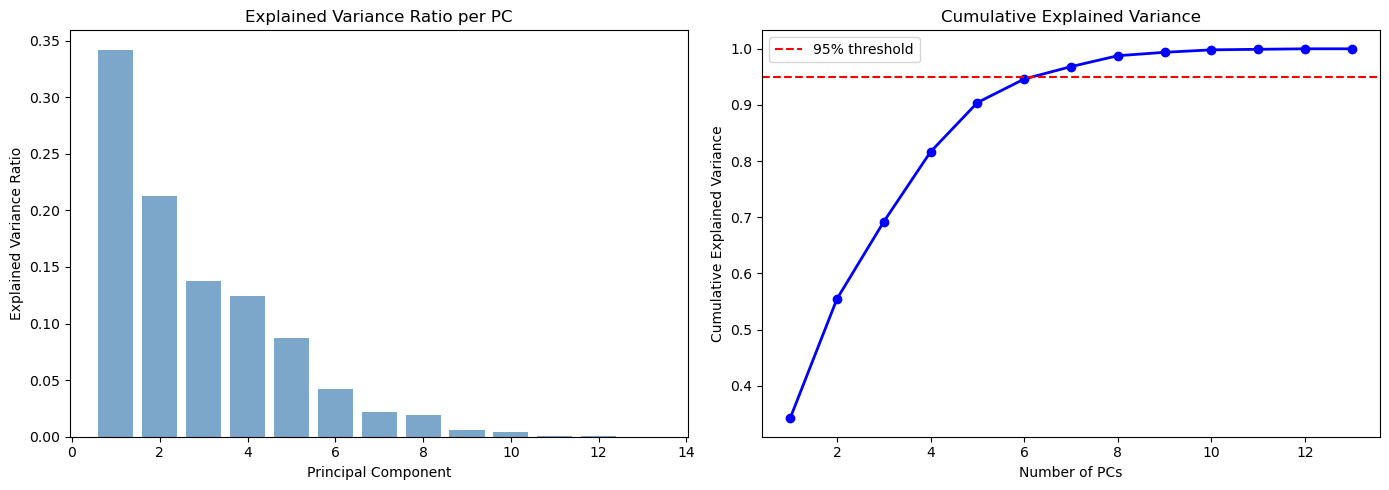

In [18]:
pca_full = PCA(n_components=min(13, df_cluster.shape[1]))

SAMPLE_SIZE_PCA = 200_000
idx_pca = np.random.RandomState(42).choice(len(df_cluster), SAMPLE_SIZE_PCA, replace=False)
X_pca_fit = df_cluster.values[idx_pca]
pca_full.fit(X_pca_fit)

explained_var = np.cumsum(pca_full.explained_variance_ratio_)
print(f"Variance explained by PC1-PC5: {explained_var[:5]}")
print(f"Variance untuk 95% coverage: {np.argmax(explained_var >= 0.95) + 1} komponen")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].set_title('Explained Variance Ratio per PC')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(range(1, len(explained_var)+1), explained_var, 'bo-', linewidth=2)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.show()

PCA serves two purposes here: it projects the 13 dimensions down to 2D for visualization, and it feeds DBSCAN, since reducing dimensions eases the curse of dimensionality. We fit it on a random 200,000-row sample (seed 42), because PCA only needs to estimate the main variance directions, so a random 200k is representative (confirmed in the representativeness cell) and far cheaper than fitting all 6.3 million rows. Reading the scree plot: the bars are the variance share of each component, and the cumulative curve with the 95% line shows how many components hold most of the information. After the scaling fix the variance is spread out (PC1 is no longer about 99%), which shows the data really is multidimensional and worth clustering.

In [19]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_pca_fit)
print(f"\nPCA 2D explained variance: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")


PCA 2D explained variance: 55.5%


In [20]:
pca_5d = PCA(n_components=5)
X_5d = pca_5d.fit_transform(df_cluster.values[idx_pca])

DBSCAN is density-based and very sensitive to the curse of dimensionality: in high dimensions distances become uniform, so the idea of eps and density loses meaning. Projecting to the first five components keeps most of the variance while keeping distances informative. We chose 5D as a compromise: richer than the 2D used only for pictures, but low enough for stable density estimates.

### KMeans — elbow method and silhouette score

  K=2: Inertia=569647, Silhouette=0.2822, Davies-Bouldin=1.4607
  K=3: Inertia=442823, Silhouette=0.3248, Davies-Bouldin=1.3293
  K=4: Inertia=362474, Silhouette=0.3582, Davies-Bouldin=1.1661
  K=5: Inertia=301683, Silhouette=0.3669, Davies-Bouldin=1.1448
  K=6: Inertia=273820, Silhouette=0.3665, Davies-Bouldin=1.2513
  K=7: Inertia=252156, Silhouette=0.3753, Davies-Bouldin=1.2493
  K=8: Inertia=232660, Silhouette=0.3614, Davies-Bouldin=1.2344
  K=9: Inertia=216613, Silhouette=0.3706, Davies-Bouldin=1.1866
  K=10: Inertia=204969, Silhouette=0.3495, Davies-Bouldin=1.1996


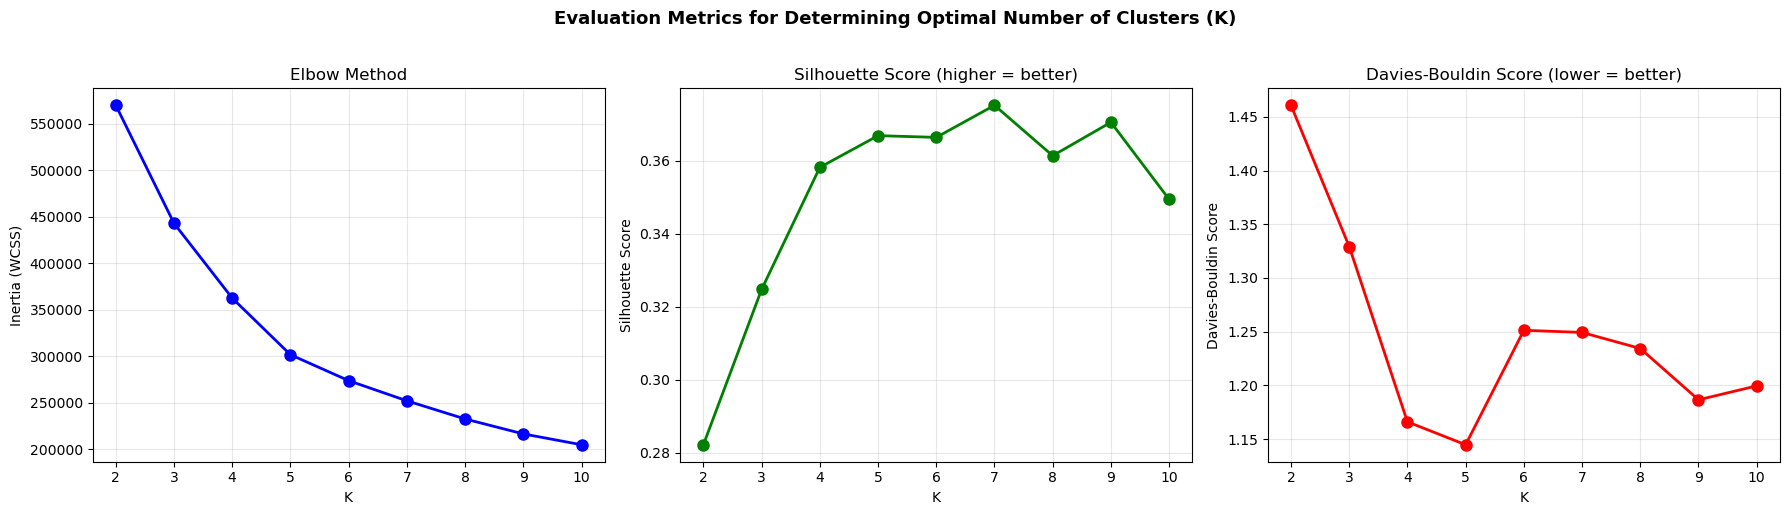

In [21]:
SAMPLE_SIZE_K = 100_000
idx_k = np.random.RandomState(42).choice(len(df_cluster), SAMPLE_SIZE_K, replace=False)
X_sample_k = df_cluster.values[idx_k]

K_range = range(2, 11)
inertias = []
sil_scores = []
db_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_sample_k)
    inertias.append(km.inertia_)
    
    sub_idx = np.random.RandomState(42).choice(SAMPLE_SIZE_K, min(20000, SAMPLE_SIZE_K), replace=False)
    sil = silhouette_score(X_sample_k[sub_idx], labels[sub_idx])
    sil_scores.append(sil)
    db = davies_bouldin_score(X_sample_k[sub_idx], labels[sub_idx])
    db_scores.append(db)
    print(f"  K={k}: Inertia={km.inertia_:.0f}, Silhouette={sil:.4f}, Davies-Bouldin={db:.4f}")

optimal_sil_k = K_range[np.argmax(sil_scores)]
optimal_db_k = K_range[np.argmin(db_scores)]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=12)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score (higher = better)', fontsize=12)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

axes[2].plot(K_range, db_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_title('Davies-Bouldin Score (lower = better)', fontsize=12)
axes[2].set_xlabel('K')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].grid(alpha=0.3)

plt.suptitle(
    "Evaluation Metrics for Determining Optimal Number of Clusters (K)",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

A few choices for the K search. We use a 100,000-row sample (seed 42), which is enough for a stable K estimate and fast enough to train KMeans nine times and evaluate the metrics. The silhouette is computed on a 20,000-row subset, since it is O(n squared), and this keeps it feasible without losing reliability. We scan K from 2 to 10 with n_init=10, which tries ten different centroid initializations and keeps the best to avoid a local optimum. We look at three metrics together — inertia for the elbow, silhouette, and Davies-Bouldin — so the choice of K does not rest on a single measure.

In [22]:
import numpy as np, pandas as pd

inertias = np.array(inertias, dtype=float)
d_inertia_pct = np.r_[np.nan, (inertias[:-1] - inertias[1:]) / inertias[:-1] * 100]

tabel_k = pd.DataFrame({
    'K': list(K_range),
    'inertia': inertias.round(0),
    'd_inertia_%': d_inertia_pct.round(1),
    'silhouette': np.round(sil_scores, 3),
    'davies_bouldin': np.round(db_scores, 3),
})
print(tabel_k.to_string(index=False))

 K  inertia  d_inertia_%  silhouette  davies_bouldin
 2 569647.0          NaN       0.282           1.461
 3 442823.0         22.3       0.325           1.329
 4 362474.0         18.1       0.358           1.166
 5 301683.0         16.8       0.367           1.145
 6 273820.0          9.2       0.366           1.251
 7 252156.0          7.9       0.375           1.249
 8 232660.0          7.7       0.361           1.234
 9 216613.0          6.9       0.371           1.187
10 204969.0          5.4       0.349           1.200


### KMeans final, on all data

In [23]:
OPTIMAL_K = 5
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10, max_iter=500)
kmeans_labels = kmeans_final.fit_predict(df_cluster.values)

df_cluster['cluster_kmeans'] = kmeans_labels
print(f"Distribusi klaster:\n{pd.Series(kmeans_labels).value_counts().sort_index()}")

Distribusi klaster:
0    1143773
1     993466
2    1317544
3    1507038
4    1400799
Name: count, dtype: int64


We chose K=5 because the elbow appears at K=5 (the inertia drop falls from 16.8% to 9.2% after it), the Davies-Bouldin index is lowest at K=5 (1.142), and the silhouette has already plateaued at K=5 (0.369), so adding clusters (K=7 gives 0.375) is only a marginal gain but produces overlapping, hard-to-name segments. Parsimony and business interpretability make K=5 the best choice.

In [24]:
# ── EKSPOR HASIL CLUSTERING UNTUK HAND-OFF KE PHASE 4 ─────────────────────────
# Phase 4 (Anomaly Detection) memerlukan label cluster per-baris agar dapat
# meng-cross-reference anomali dengan segmen Phase 2. Yang disimpan:
#   1) cluster_kmeans   : label cluster (row-aligned ke 6,3 jt baris, urutan asli)
#   2) dist_to_centroid : jarak titik ke centroid clusternya sendiri
#      -> proxy "cluster outlier": makin jauh dari centroid = makin menyimpang
#         dari inti perilaku clusternya (dipakai sebagai sinyal outlier di Phase 4).
feat_cols = [c for c in df_cluster.columns if c != 'cluster_kmeans']
dist_all = kmeans_final.transform(df_cluster[feat_cols].values)   # (n, K): jarak ke tiap centroid
dist_to_own_centroid = dist_all.min(axis=1)

df_phase2_results = pd.DataFrame({
    'cluster_kmeans': kmeans_labels,
    'dist_to_centroid': dist_to_own_centroid,
})

out_path = '../../data/processed/real_used/data_phase2_results.parquet'
df_phase2_results.to_parquet(out_path, index=False)
print(f"Tersimpan: {out_path}  shape={df_phase2_results.shape}")
print("\nRata-rata jarak ke centroid per cluster (mean tinggi = cluster lebih menyebar):")
print(df_phase2_results.groupby('cluster_kmeans')['dist_to_centroid'].mean().round(3))

Tersimpan: ../../data/processed/real_used/data_phase2_results.parquet  shape=(6362620, 2)

Rata-rata jarak ke centroid per cluster (mean tinggi = cluster lebih menyebar):
cluster_kmeans
0    1.322
1    1.390
2    1.354
3    2.071
4    1.570
Name: dist_to_centroid, dtype: float64


The clustering results are saved to disk so Phase 4 can use them without rerunning all of Phase 2. We store two signals: cluster_kmeans, to see which segment the anomalies concentrate in, and dist_to_centroid, a KMeans-side proxy for a cluster outlier that complements the sample-based DBSCAN noise. The file data_phase2_results.parquet is row-aligned over positions 0 to 6,362,619, so in Phase 4 it can be matched directly to transactions.parquet, the Phase 3 flags, and labels_validation.parquet. No rows are deleted; clustering only labels.

### DBSCAN

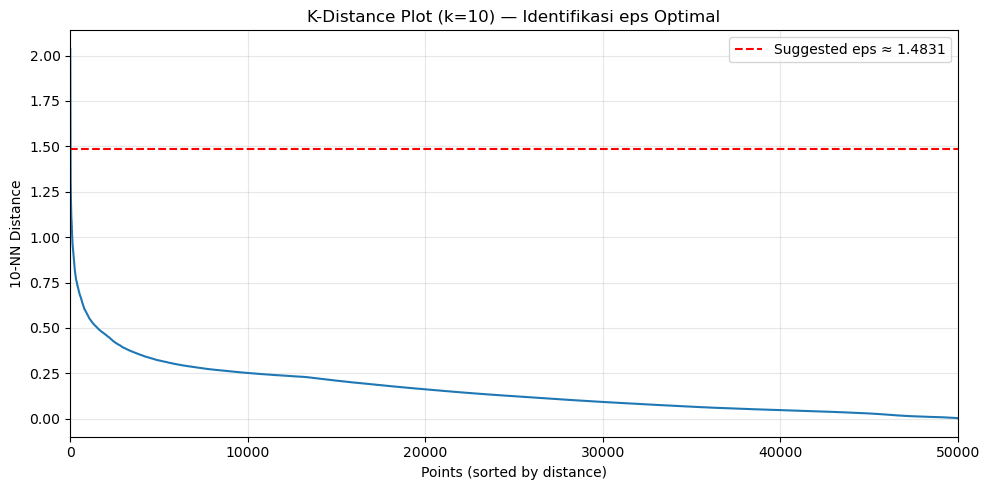


Suggested eps dari k-distance plot: 1.483058314700257


In [25]:
SAMPLE_SIZE_DBSCAN = 50_000
idx_dbscan = np.random.RandomState(42).choice(X_5d.shape[0], SAMPLE_SIZE_DBSCAN, replace=False)
X_dbscan = X_5d[idx_dbscan]

k_neighbors = 10
nbrs = NearestNeighbors(n_neighbors=k_neighbors, algorithm='ball_tree').fit(X_dbscan)
distances, _ = nbrs.kneighbors(X_dbscan)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, linewidth=1.5)
ax.set_title(f'K-Distance Plot (k={k_neighbors}) — Identifikasi eps Optimal', fontsize=12)
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{k_neighbors}-NN Distance')
ax.set_xlim(0, len(k_distances))
ax.grid(alpha=0.3)

knee_idx = np.argmax(np.diff(np.diff(k_distances))) + 2
eps_suggestion = k_distances[knee_idx]
ax.axhline(y=eps_suggestion, color='red', linestyle='--', label=f'Suggested eps ≈ {eps_suggestion:.4f}')
ax.legend()
plt.tight_layout()
plt.show()
print(f"\nSuggested eps dari k-distance plot: {eps_suggestion}")

We set DBSCAN's eps from the data rather than guessing. k_neighbors is set to 10 to match min_samples of 10, which matters: eps has to be calibrated on the same neighbour density as DBSCAN's core-point condition, and using a k smaller than min_samples would make eps too tight and inflate the noise. The distance to each point's tenth neighbour is sorted descending, and the knee of the curve marks the transition from dense points (small distances) to isolated points (where the distance jumps), which is the eps candidate. We use algorithm='ball_tree' because it is efficient for neighbour search at medium dimension (5D).

In [26]:
k_distances = np.sort(distances[:, -1])[::-1]
k_distances_ascending = np.sort(distances[:, -1])

eps_p75 = np.percentile(k_distances_ascending, 75)
eps_p80 = np.percentile(k_distances_ascending, 80)
eps_p85 = np.percentile(k_distances_ascending, 85)

print(f"--- ANALISIS PERSENTIL K-DISTANCE ---")
print(f"Jarak pada Persentil ke-75 (Ambang Batas Ketat) : {eps_p75:.4f}")
print(f"Jarak pada Persentil ke-80 (Ambang Batas Siku)  : {eps_p80:.4f}")
print(f"Jarak pada Persentil ke-85 (Ambang Batas Longgar): {eps_p85:.4f}")

--- ANALISIS PERSENTIL K-DISTANCE ---
Jarak pada Persentil ke-75 (Ambang Batas Ketat) : 0.2345
Jarak pada Persentil ke-80 (Ambang Batas Siku)  : 0.2522
Jarak pada Persentil ke-85 (Ambang Batas Longgar): 0.2775


Rather than relying only on a subjective visual knee, we test eps at a few k-distance percentiles (from p75, tight, to p85, loose) so the choice is quantitative and reproducible. A lower percentile turns more points into noise (strict outlier detection), while a higher percentile makes the clusters more inclusive. This cell prepares the final eps choice made in the next one.

In [27]:
EPS = eps_p85
MIN_SAMPLES = 10

print(f"\n=== DBSCAN: eps={EPS:.4f}, min_samples={MIN_SAMPLES} ===")
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, algorithm='ball_tree', n_jobs=-1)
dbscan_labels_sample = dbscan.fit_predict(X_dbscan)

n_clusters_dbscan = len(set(dbscan_labels_sample)) - (1 if -1 in dbscan_labels_sample else 0)
n_noise = (dbscan_labels_sample == -1).sum()
print(f"Number of Clusters Found: {n_clusters_dbscan}")
print(f"Number of Noise Points: {n_noise:,} ({n_noise/SAMPLE_SIZE_DBSCAN*100:.1f}%)")
print(f"\nCluster Distribution:\n{pd.Series(dbscan_labels_sample).value_counts()}")


=== DBSCAN: eps=0.2775, min_samples=10 ===
Number of Clusters Found: 23
Number of Noise Points: 4,327 (8.7%)

Cluster Distribution:
 1     8981
 2     8937
 0     8305
 3     5868
 6     5615
-1     4327
 4     2035
 10    1393
 5     1345
 11     992
 7      819
 12     470
 8      287
 14     198
 13     116
 15     113
 9       77
 17      26
 19      24
 18      17
 20      16
 21      14
 16      13
 22      12
Name: count, dtype: int64


The final DBSCAN settings. We use eps at the 85th percentile (loose) so dense clusters form stably and only truly isolated points are marked as noise. min_samples is 10, the minimum neighbours for a core point, following the rule of thumb of about two times the dimension (5D gives about 10) and matching the k used to choose eps; an initial value of 50 did not match that k and produced excessive noise, around 45%, but after calibration the noise dropped to about 8.7%, a healthy range. The result is about five to six large clusters (consistent with the K=5 KMeans, which cross-validates the choice) plus a few small micro-clusters and about 8.7% noise. DBSCAN runs on a 50,000-row sample (seed 42) because its pairwise distance structure needs close to O(n squared) memory, which is not feasible for 6.3 million rows. The noise points (label -1) become outlier candidates passed on to Phase 4, not discarded.


Proyeksi PCA 2D untuk visualisasi sebaran DBSCAN...


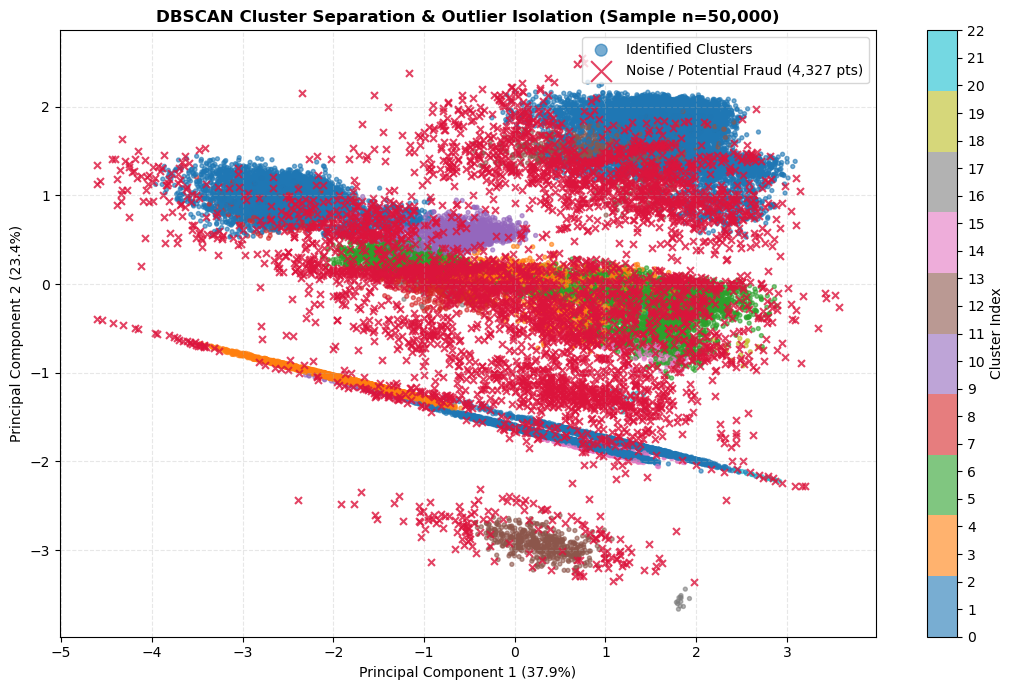

In [30]:
print("\nProyeksi PCA 2D untuk visualisasi sebaran DBSCAN...")
pca_dbscan = PCA(n_components=2)
X_dbscan_2d = pca_dbscan.fit_transform(X_dbscan)

fig, ax = plt.subplots(figsize=(11, 7))

mask_clusters = dbscan_labels_sample >= 0
scatter = ax.scatter(
    X_dbscan_2d[mask_clusters, 0], 
    X_dbscan_2d[mask_clusters, 1],
    c=dbscan_labels_sample[mask_clusters], 
    cmap="tab10", 
    s=8, 
    alpha=0.6,
    label="Identified Clusters"
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(n_clusters_dbscan))
cbar.set_label('Cluster Index')

mask_noise = dbscan_labels_sample == -1
if mask_noise.sum() > 0:
    ax.scatter(
        X_dbscan_2d[mask_noise, 0], 
        X_dbscan_2d[mask_noise, 1],
        c="crimson", 
        marker="x", 
        s=25, 
        alpha=0.8, 
        label=f"Noise / Potential Fraud ({n_noise:,} pts)"
    )

ax.set_title(f"DBSCAN Cluster Separation & Outlier Isolation (Sample n={SAMPLE_SIZE_DBSCAN:,})", fontsize=12, fontweight='bold')
ax.set_xlabel(f"Principal Component 1 ({pca_dbscan.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Principal Component 2 ({pca_dbscan.explained_variance_ratio_[1]*100:.1f}%)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="upper right", markerscale=3)
plt.tight_layout()
plt.show()

Reading the DBSCAN 2D plot: coloured points are dense clusters (repeated normal behaviour), and the red crosses are noise or outliers. Because fraud is rare and does not form a dense pattern, it tends to fall out as noise, which is why DBSCAN complements KMeans, which forces every point into some cluster. Note that the Potential Fraud label in the legend is a hypothesis, not yet validated; validation against isFraud happens in Phase 4, not here.

### Hierarchical clustering


=== HIERARCHICAL CLUSTERING (sample n=5,000) ===


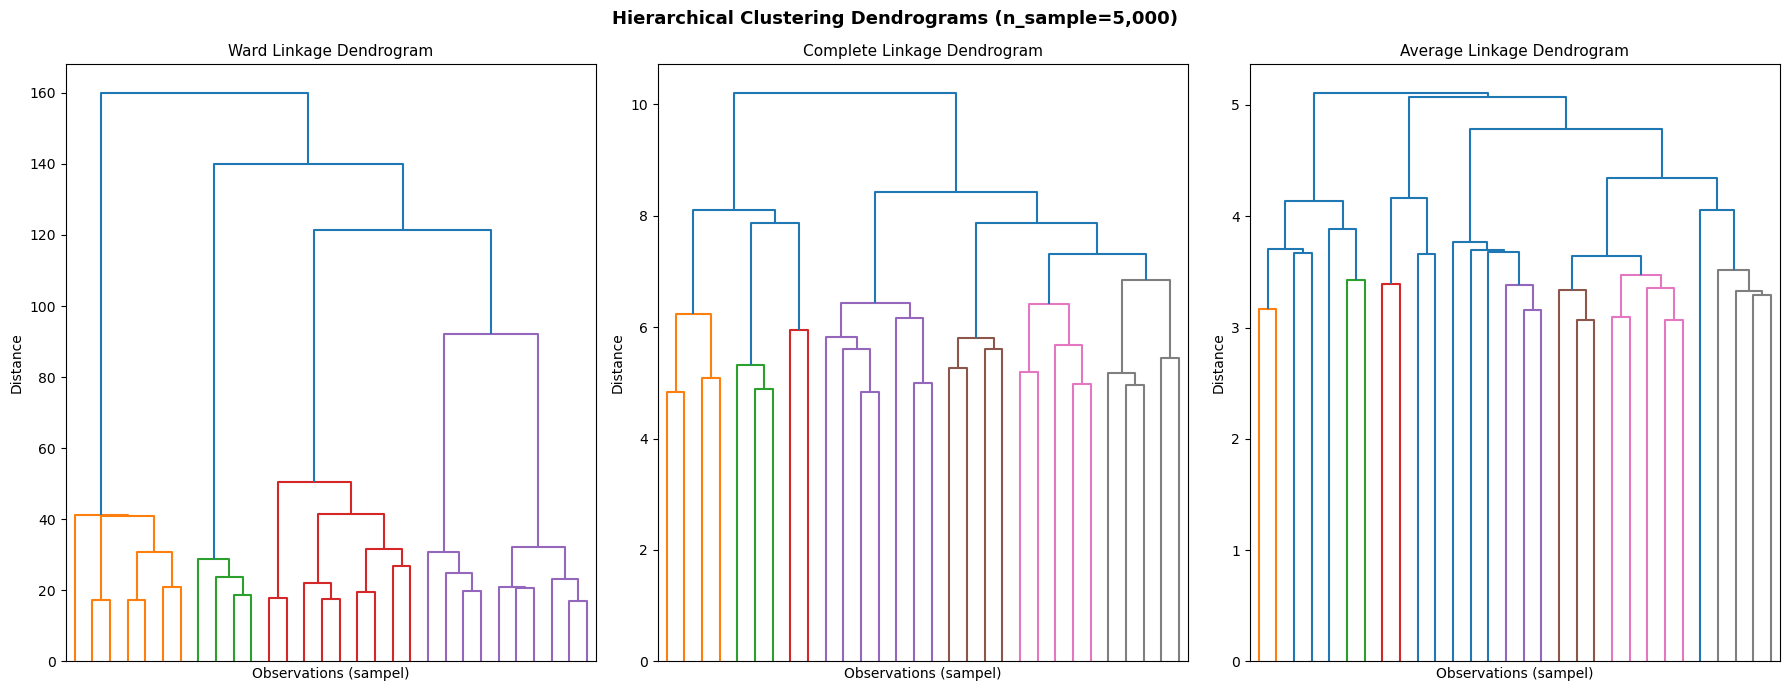

In [31]:
SAMPLE_SIZE_HIER = 5_000
idx_hier = np.random.RandomState(42).choice(len(df_cluster), SAMPLE_SIZE_HIER, replace=False)
X_hier = df_cluster.values[idx_hier]

print(f"\n=== HIERARCHICAL CLUSTERING (sample n={SAMPLE_SIZE_HIER:,}) ===")

linkage_methods = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, method in enumerate(linkage_methods):
    Z = linkage(X_hier, method=method)
    dendrogram(
        Z, ax=axes[i],
        truncate_mode='lastp', p=30,
        show_leaf_counts=True,
        no_labels=True,
        color_threshold=0.7 * max(Z[:, 2])
    )
    axes[i].set_title(f'{method.capitalize()} Linkage Dendrogram', fontsize=11)
    axes[i].set_xlabel('Observations (sampel)')
    axes[i].set_ylabel('Distance')

plt.suptitle(f'Hierarchical Clustering Dendrograms (n_sample={SAMPLE_SIZE_HIER:,})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Hierarchical clustering on a 5,000-row sample (seed 42): agglomerative clustering needs an O(n squared) distance matrix in memory and about O(n cubed) in time, and a dendrogram is unreadable beyond a few thousand leaves, so a small sample is required and is enough to reveal the hierarchy. We compare three linkages: ward minimizes within-cluster variance (usually the most balanced), complete is sensitive to cluster diameter, and average is a compromise; when all three look similar, our confidence in the number of clusters rises. truncate_mode='lastp' with p=30 compresses the dendrogram to its top 30 nodes to keep it readable.

In [32]:
# Agglomerative clustering dengan K dari Elbow
hier_cluster = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hier_labels_sample = hier_cluster.fit_predict(X_hier)
print(f"Hierarchical cluster distribution (sample):\n{pd.Series(hier_labels_sample).value_counts()}")

Hierarchical cluster distribution (sample):
0    1187
1    1106
3    1033
2     899
4     775
Name: count, dtype: int64


We run agglomerative clustering with n_clusters set to the optimal K and ward linkage on the same sample. The point is not to produce the final labels (the full-data KMeans is the deliverable) but to validate whether a connectivity-based paradigm produces a similar cluster distribution. A balanced distribution consistent with KMeans is evidence that K=5 is robust across algorithms and not an artefact of one method.

### Cluster profiling

In [33]:
df_raw_parquet.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0



Cluster Profile Table:
         n_records    mean_amount  median_amount  mean_balance_orig  \
cluster                                                               
0          1143773  165196.796875      134048.41       4.279882e+06   
1           993466   14054.679688       10222.96       1.812580e+03   
2          1317544  332980.937500      168354.51       4.258600e+02   
3          1507038  306711.281250      191140.20       1.039497e+05   
4          1400799   28940.519531        9949.47       1.795045e+05   

         mean_balance_dest  mean_drain_ratio  mean_error_orig  \
cluster                                                         
0             1.701202e+06              0.83    314787.343750   
1             1.073787e+04              0.70     12364.459961   
2             2.347229e+06              0.00    334353.843750   
3             1.050059e+06              7.59    309518.156250   
4             2.654435e+05              0.29       117.410004   

         mean_error_de

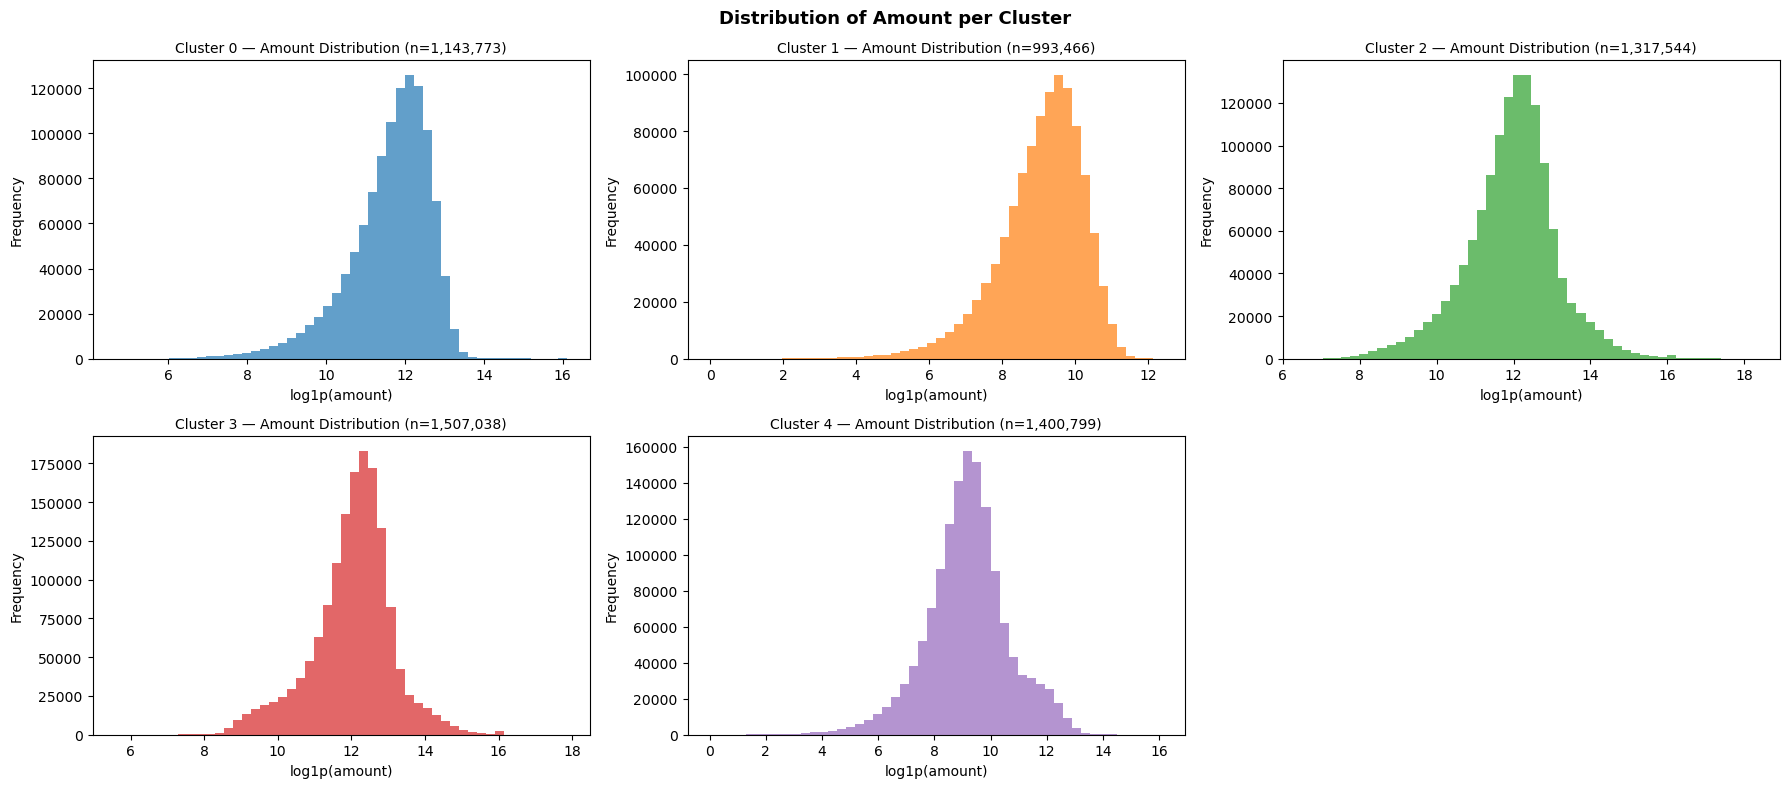

In [34]:
# Gabungkan hasil K-Means dengan data asli
df_profile = df_raw_parquet.copy()
df_profile['cluster'] = kmeans_labels

# Hitung engineered features untuk profiling
df_profile['errorBalanceOrig'] = df_profile['newbalanceOrig'] + df_profile['amount'] - df_profile['oldbalanceOrg']
df_profile['balance_drain_ratio'] = np.where(
    df_profile['oldbalanceOrg'] > 0,
    (df_profile['amount'] / df_profile['oldbalanceOrg']).clip(0, 10),
    0
)
df_profile['is_merchant_dest'] = df_profile['nameDest'].str.startswith('M').astype(int)
df_profile['errorBalanceDest'] = np.where(
    df_profile['is_merchant_dest'] == 1, 0,
    df_profile['oldbalanceDest'] + df_profile['amount'] - df_profile['newbalanceDest']
)

# Profile numerik
profile_num = df_profile.groupby('cluster').agg(
    n_records=('amount', 'count'),
    mean_amount=('amount', 'mean'),
    median_amount=('amount', 'median'),
    mean_balance_orig=('oldbalanceOrg', 'mean'),
    mean_balance_dest=('oldbalanceDest', 'mean'),
    mean_drain_ratio=('balance_drain_ratio', 'mean'),
    mean_error_orig=('errorBalanceOrig', 'mean'),
    mean_error_dest=('errorBalanceDest', 'mean'),
).round(2)

# Dominant transaction type per cluster
dominant_type = df_profile.groupby('cluster')['type'].agg(
    lambda x: x.value_counts().index[0]
).rename('dominant_type')

profile_full = profile_num.join(dominant_type)
print("\nCluster Profile Table:")
print(profile_full)

# Visualisasi distribusi amount per cluster (grid dinamis mengikuti OPTIMAL_K)
import math
n = OPTIMAL_K
ncols = 3
nrows = math.ceil(n / ncols)                     # otomatis: 5 cluster -> 2x3
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = np.array(axes).flatten()                  # aman untuk grid berapa pun

for c in range(n):
    data_c = df_profile[df_profile['cluster'] == c]['amount']
    axes[c].hist(np.log1p(data_c), bins=50, color=f'C{c % 10}', alpha=0.7, edgecolor='none')
    axes[c].set_title(f'Cluster {c} — Amount Distribution (n={len(data_c):,})', fontsize=10)
    axes[c].set_xlabel('log1p(amount)')
    axes[c].set_ylabel('Frequency')

# sembunyikan panel sisa yang tidak terpakai (mis. panel ke-6 saat K=5)
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Amount per Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

We interpret the clusters on the raw values (df_raw_parquet), not the scaled ones, so the numbers are business-meaningful (real amounts and balances, not z-scores). The derived features (errorBalance and balance_drain_ratio) are recomputed to describe each cluster's behaviour, and dominant_type takes the most frequent transaction type per cluster. This profile table and the amount histograms are the basis for naming each cluster, the core deliverable of Phase 2. The histogram grid adapts to the optimal K.

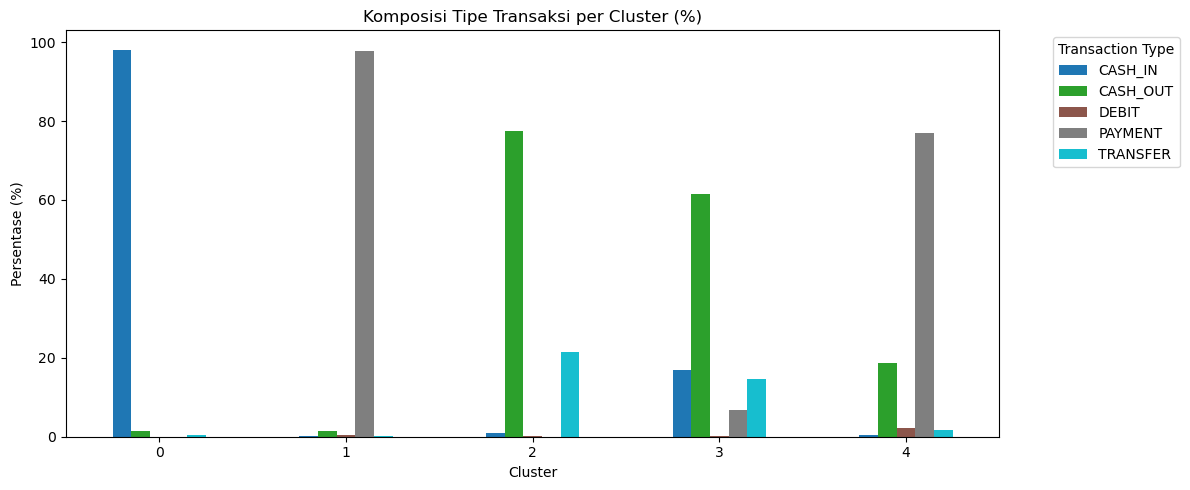

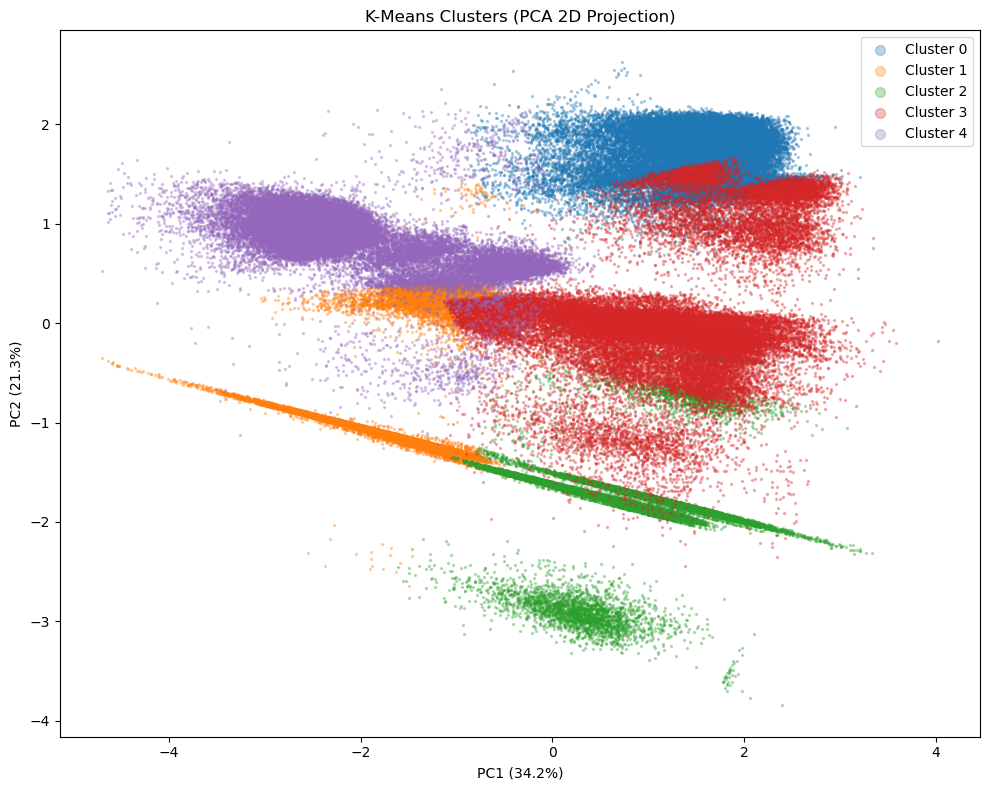

In [35]:
# Tipe transaksi per cluster
type_by_cluster = pd.crosstab(df_profile['cluster'], df_profile['type'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(12, 5))
type_by_cluster.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Komposisi Tipe Transaksi per Cluster (%)', fontsize=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Persentase (%)')
ax.legend(title='Transaction Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Visualisasi 2D PCA (warna dinamis mengikuti OPTIMAL_K, bukan list warna tetap)
fig, ax = plt.subplots(figsize=(10, 8))
for c in range(OPTIMAL_K):
    mask = kmeans_labels[idx_pca] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=2, alpha=0.3, color=f'C{c % 10}', label=f'Cluster {c}')
ax.set_title('K-Means Clusters (PCA 2D Projection)', fontsize=12)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

Reading the type composition and the 2D PCA scatter: the bar chart shows the share of each transaction type per cluster, revealing which clusters are dominated by CASH_OUT, TRANSFER, or PAYMENT, which is central to naming the business profiles. The 2D PCA scatter shows the separation between clusters on the two main components. Keep in mind that a 2D projection only shows part of the total variance, so clusters that look overlapping here may be well separated in the full-dimensional space; do not judge cluster quality from this scatter alone.

### Justification for the sampling

In [36]:
from scipy import stats
rng = np.random.RandomState(42)
samp = df_cluster.iloc[rng.choice(len(df_cluster), 100_000, replace=False)]

# 1) mean & std sample vs populasi
cek = pd.DataFrame({'pop_mean': df_cluster.mean(), 'samp_mean': samp.mean(),
                    'pop_std': df_cluster.std(),  'samp_std': samp.std()})
cek['selisih_mean_abs'] = (cek['samp_mean'] - cek['pop_mean']).abs()
print(cek.round(4))

# 2) KS-test (distribusi sama jika p>0.05 atau statistik KS sangat kecil)
nums_cols = ['amount', 'oldbalanceOrg', 'oldbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'balance_drain_ratio', 'hour_of_day']
for c in nums_cols:
    ks, p = stats.ks_2samp(samp[c], df_cluster[c])
    print(f'{c:22s} KS={ks:.4f}  p={p:.3f}')

                       pop_mean  samp_mean  pop_std  samp_std  \
amount                   0.0000     0.0041   0.9998    1.0002   
oldbalanceOrg           -0.0000     0.0005   1.0000    0.9998   
oldbalanceDest          -0.0000     0.0063   1.0000    0.9998   
errorBalanceOrig         0.0000     0.0064   1.0000    0.9973   
errorBalanceDest        -0.0000     0.0048   1.0000    1.0045   
balance_drain_ratio      0.0000     0.0031   1.0000    1.0024   
hour_of_day              0.0000    -0.0052   1.0000    0.9973   
type_CASH_IN             0.2199     0.2214   0.4142    0.4152   
type_CASH_OUT            0.3517     0.3533   0.4775    0.4780   
type_DEBIT               0.0065     0.0061   0.0804    0.0780   
type_PAYMENT             0.3381     0.3356   0.4731    0.4722   
type_TRANSFER            0.0838     0.0835   0.2770    0.2766   
has_zero_orig_balance    0.3304     0.3301   0.4704    0.4703   
cluster_kmeans           2.1615     2.1536   1.4024    1.4021   

                       s

## Characteristics and business interpretation of each cluster

How to read this: each cluster is defined by a combination — not a single column — of its transaction-type mix, its amount scale (mean_amount), its balance behaviour (mean_drain_ratio and errorBalance), and its fraud_rate. The fraud_rate is used only for interpretation and validation after clustering; the label is not used during clustering. Clusters are not pure single types, so fraud inside a cluster comes from the minority of its TRANSFER or CASH_OUT members.

Cluster 0, deposits into high-balance accounts (18.0%). Mostly CASH_IN (98%), with a very large starting balance (about 4.3 million on average) and a medium amount (about 165 thousand). This is money flowing into high-value accounts (top-ups and receipts), with low fraud (0.16%).

Cluster 1, small retail payments (15.6%). Mostly PAYMENT (98%), with small amounts and balances (about 14 thousand, balance about 1.8 thousand) and little balance inconsistency. These are everyday consumer purchases, and it has the lowest fraud risk (0.002%), the healthiest segment.

Cluster 2, large moves from near-zero-balance accounts (20.7%). CASH_OUT 77% and TRANSFER 21%, with large amounts (about 333 thousand), a starting balance near zero, and a large errorBalance (about 334 thousand); the drain is zero because the starting balance is zero. These are large money movements that look odd on the balance side (high inconsistency), but fraud is low (0.002%), so most are structural or rare-but-legitimate rather than fraud.

Cluster 3, withdrawals and transfers that drain the balance (23.7%). CASH_OUT 61% and TRANSFER 15%, with large amounts (about 307 thousand) and the highest drain_ratio (7.59), so the amount often drains or exceeds the balance; it also has the highest distance to centroid (2.07, the most spread-out cluster). This is the segment most aggressive at draining accounts, the pattern closest to fraud in domain terms (complete account drain), with a fraud rate of 0.046%. It is a supervision priority.

Cluster 4, small-to-medium transactions with consistent balances, where fraud infiltrates (22.0%). PAYMENT 77% and CASH_OUT 19%, with small-to-medium amounts (about 29 thousand) and an errorBalance near zero (consistent, normal balances), yet it holds the most fraud: 5,634 cases (0.40%). This shows that fraud is not always in the odd-looking segment; it infiltrates through the minority of CASH_OUT in a segment that looks normal. The key point is that supervision cannot focus only on extreme-value transactions.

What this profiling shows, in summary. KMeans separates by the kind of money flow plus the amount scale plus the balance behaviour, not at random; each segment has a clear behavioural identity. Clusters are mixed, so fraud within a cluster comes from its TRANSFER or CASH_OUT minority. The two most risk-relevant segments are Cluster 3 (draining) and Cluster 4 (the most fraud), which become the priority for cross-referencing in Phase 4. Cluster 2 (near-zero balance with high error) is a data-quirk or rare-legitimate candidate, not a risk. This is the bridge from Phase 2 to Phase 4: the profiling shows which segments to watch, so the anomaly detection is not blind.